In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import time
import matplotlib.pyplot as plt

In [ ]:
vocab_size = 10000
max_len = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def build_lstm():
    model = models.Sequential([
        layers.Embedding(vocab_size, 128, input_length=max_len),
        layers.LSTM(128),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
def build_gru():
    model = models.Sequential([
        layers.Embedding(vocab_size, 128, input_length=max_len),
        layers.GRU(128),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
lstm_model = build_lstm()

start = time.time()
history_lstm = lstm_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)
lstm_time = time.time() - start

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 169s 533ms/step - accuracy: 0.7909 - loss: 0.4370 - val_accuracy: 0.8548 - val_loss: 0.3369
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 158s 506ms/step - accuracy: 0.8967 - loss: 0.2597 - val_accuracy: 0.8722 - val_loss: 0.3212
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 160s 510ms/step - accuracy: 0.9336 - loss: 0.1780 - val_accuracy: 0.8694 - val_loss: 0.3498
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 159s 509ms/step - accuracy: 0.9561 - loss: 0.1249 - val_accuracy: 0.8590 - val_loss: 0.4289
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 158s 505ms/step - accuracy: 0.9680 - loss: 0.0963 - val_accuracy: 0.8536 - val_loss: 0.4762


In [ ]:
gru_model = build_gru()

start = time.time()
history_gru = gru_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)
gru_time = time.time() - start

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 162s 509ms/step - accuracy: 0.7239 - loss: 0.5285 - val_accuracy: 0.8532 - val_loss: 0.3557
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 161s 514ms/step - accuracy: 0.8863 - loss: 0.2756 - val_accuracy: 0.8726 - val_loss: 0.3086
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 157s 502ms/step - accuracy: 0.9294 - loss: 0.1838 - val_accuracy: 0.8686 - val_loss: 0.3287
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 157s 502ms/step - accuracy: 0.9577 - loss: 0.1203 - val_accuracy: 0.8550 - val_loss: 0.4001
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 158s 506ms/step - accuracy: 0.9734 - loss: 0.0788 - val_accuracy: 0.8490 - val_loss: 0.4454


In [ ]:
lstm_loss, lstm_acc = lstm_model.evaluate(x_test, y_test)
gru_loss, gru_acc = gru_model.evaluate(x_test, y_test)

print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy:", gru_acc)
print("LSTM Training Time:", lstm_time)
print("GRU Training Time:", gru_time)

782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 102ms/step - accuracy: 0.8492 - loss: 0.4901
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.8526 - loss: 0.4537
LSTM Accuracy: 0.8491600155830383
GRU Accuracy: 0.8526399731636047
LSTM Training Time: 848.5253884792328
GRU Training Time: 795.5832941532135


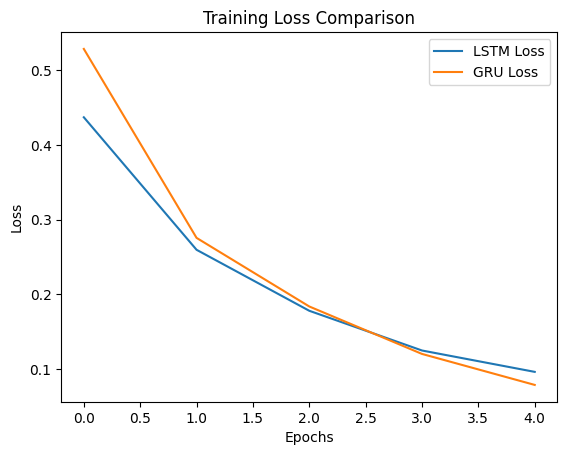

In [ ]:
plt.plot(history_lstm.history['loss'], label='LSTM Loss')
plt.plot(history_gru.history['loss'], label='GRU Loss')
plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

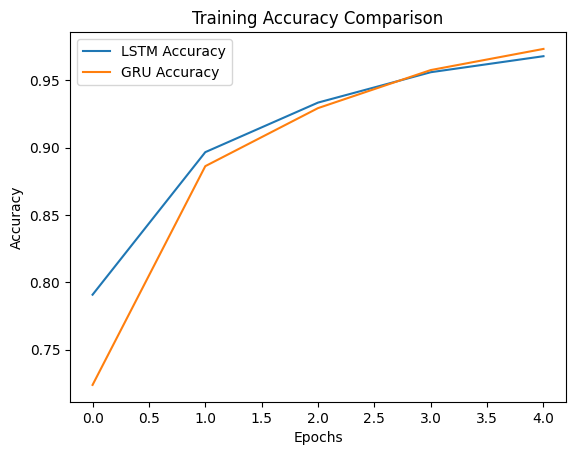

In [ ]:
plt.plot(history_lstm.history['accuracy'], label='LSTM Accuracy')
plt.plot(history_gru.history['accuracy'], label='GRU Accuracy')
plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()